# Figure 2 - Multilayer learning: Backprop vs Hebb

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/data_utils.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
figure_name = "Fig2_vanBP_bpDale_hebb"
model_list = ["vanBP", "bpDale_learned", "HebbWN_topsup"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

In [7]:
def generate_figure_2(model_dict_all, model_list, figure_name, figsize=(6.5, 3.8)):
    fig = plt.figure(figsize=figsize)
    axes = gs.GridSpec(nrows=3, ncols=len(model_list), figure=fig,                    
                        left=0.06,right=0.7,
                        top=0.95, bottom=0.05,
                        wspace=0.2, hspace=0.4)
    axes_metrics = gs.GridSpec(nrows=3, ncols=1, figure=fig,
                        left=0.82,right=0.99,
                        top=0.95, bottom=0.05,
                        wspace=0.2, hspace=0.4)

    ax_accuracy    = fig.add_subplot(axes_metrics[0])  
    ax_sparsity   = fig.add_subplot(axes_metrics[1])
    ax_selectivity = fig.add_subplot(axes_metrics[2])
    root_dir = ut.get_project_root()

    for col, model_key in enumerate(model_list):
        model_dict = model_dict_all[model_key]
        network_name = model_dict['config'].split('.')[0]
        hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
        with h5py.File(hdf5_path, 'r') as f:
            data_dict = f[network_name]
            print(f"Generating plots for {model_dict['label']}")

            plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy, legend=True)

            #########################################################
            # Plot sparsity and selectivity bar charts
            #########################################################
            bar_width = 0.2
            group_spacing = 0.5
            within_group_spacing = 0.25
            sparsity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
            selectivity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
            for seed in data_dict:
                for population in sparsity_all_seeds:
                    avg_sparsity = np.mean(data_dict[seed][f"metrics_dict_{population}"]["sparsity"])
                    sparsity_all_seeds[population].append(avg_sparsity)
                    avg_selectivity = np.mean(data_dict[seed][f"metrics_dict_{population}"]["selectivity"])
                    selectivity_all_seeds[population].append(avg_selectivity)
            if col == 0: # Plot InputE bar
                input_sparsity_data = sparsity_all_seeds['InputE']
                input_selectivity_data = selectivity_all_seeds['InputE']
                ax_sparsity.bar(0, np.mean(input_sparsity_data), color='gray', width=bar_width, alpha=0.5, 
                            error_kw={'ecolor': 'black', 'capsize': 3})
                ax_selectivity.bar(0, np.mean(input_selectivity_data), color='gray', width=bar_width, alpha=0.5, 
                                error_kw={'ecolor': 'black', 'capsize': 3})
            x1 = group_spacing + col * within_group_spacing
            x2 = 2 * group_spacing + (len(model_list) - 1)*within_group_spacing + col*within_group_spacing
            
            ax_sparsity.bar(x1, np.mean(sparsity_all_seeds['H1E']), yerr=np.std(sparsity_all_seeds['H1E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            ax_sparsity.bar(x2, np.mean(sparsity_all_seeds['H2E']), yerr=np.std(sparsity_all_seeds['H2E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            ax_selectivity.bar(x1, np.mean(selectivity_all_seeds['H1E']), yerr=np.std(selectivity_all_seeds['H1E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            ax_selectivity.bar(x2, np.mean(selectivity_all_seeds['H2E']), yerr=np.std(selectivity_all_seeds['H2E']), color=model_dict["color"], width=bar_width, alpha=0.5)

            h1e_center = group_spacing + (len(model_list) - 1) * within_group_spacing / 2
            h2e_center = 2 * group_spacing + (len(model_list) - 1) * within_group_spacing + (len(model_list) - 1) * within_group_spacing / 2

            ax_sparsity.set_xticks([0, h1e_center, h2e_center])
            ax_sparsity.set_xticklabels(['Input', 'H1E', 'H2E'], rotation=0, ha='center')
            ax_sparsity.set_ylabel('Sparsity')
            ax_sparsity.set_ylim([0, 1])
            ax_sparsity.tick_params(axis='x', length=0)

            ax_selectivity.set_xticks([0, h1e_center, h2e_center])
            ax_selectivity.set_xticklabels(['Input', 'H1E', 'H2E'], rotation=0, ha='center')
            ax_selectivity.set_ylabel('Selectivity')
            ax_selectivity.set_ylim([0, 1])
            ax_selectivity.tick_params(axis='x', length=0)


            #########################################################
            # Example heatmaps for E populations
            #########################################################
            example_seed = model_dict['seeds'][0]
            ax1 = fig.add_subplot(axes[0, col])
            ax2 = fig.add_subplot(axes[1, col])
            ax1.set_ylabel('OutputE unit', labelpad=-7)
            ax2.set_ylabel('H2E unit', labelpad=-11)        
            ax = [ax1, ax2]
            for row, population in enumerate(['OutputE', 'H1E']):
                # Activity plots: batch accuracy of each population to the test dataset
                average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
                num_units = average_pop_activity_dict[population].shape[1]
                pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax[row], cbar=True)    
                ax[row].set_yticks([0,num_units-1])
                ax[row].set_yticklabels([1,num_units])
                if col > 0:
                    ax[row].set_yticklabels([])
                    ax[row].set_ylabel('')
                    if col == len(model_list)-1:
                        cbar = ax[row]._colorbars[0]
                        cbar.set_label('Average activity', rotation=270, labelpad=8)        
            ax1.set_title(model_dict["display_name"])

            #########################################################
            # Class confusion bar graphs
            #########################################################
            population = 'H1E'
            between_class_similarity = {label: [] for label in range(10)}
            between_class_similarity_all = []
            for seed in model_dict['seeds']:
                # Calculate the receptive field similarity for each unit (the histogram will pool data across all model seeds)
                unit_labels_dict = data_dict[seed]['unit_labels_dict']
                unit_labels = unit_labels_dict[population][:]
                idx = np.argsort(unit_labels)
                unit_labels = unit_labels[idx]

                average_pop_activity = np.array(data_dict[seed]['average_pop_activity_dict'][population][:]).T
                sorted_pop_activity = average_pop_activity[idx]

                # Calculate within-class and between-class receptive field similarity (accumulate across all seeds)
                for label in range(10):
                    class_idx = np.where(unit_labels == label)[0]
                    max_activity_outside_class = np.max(sorted_pop_activity[class_idx][:, np.arange(10)!=label], axis=1)
                    mean_activity_outside_class = np.mean(sorted_pop_activity[class_idx][:, np.arange(10)!=label], axis=1)
                    confusion_ratio = max_activity_outside_class / (mean_activity_outside_class + 1e-10)
                    between_class_similarity_all.extend(confusion_ratio)
                    between_class_similarity[label].extend(confusion_ratio)

            ax = fig.add_subplot(axes[2, col])
            for label in range(10):
                mean_val = np.mean(between_class_similarity[label])
                std_val = np.std(between_class_similarity[label])
                ax.bar(label, mean_val, width=0.8, label='Between-class' if label==0 else None, color='gray', alpha=0.4)
                ax.errorbar(label, mean_val, yerr=std_val, fmt='none', ecolor='gray', capsize=0, linewidth=0.5)
            if col == 0:
                ax.set_ylabel('Confusion ratio (max/mean \nout-of-class activity)')
            ax.set_xticks(range(10))
            ax.set_xticklabels(range(10))
            ax.set_ylim(0, 8)

    fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)
    fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)

Generating plots for Backprop (ANN)
Generating plots for Backprop (EIANN)
Generating plots for Hebb (EIANN)


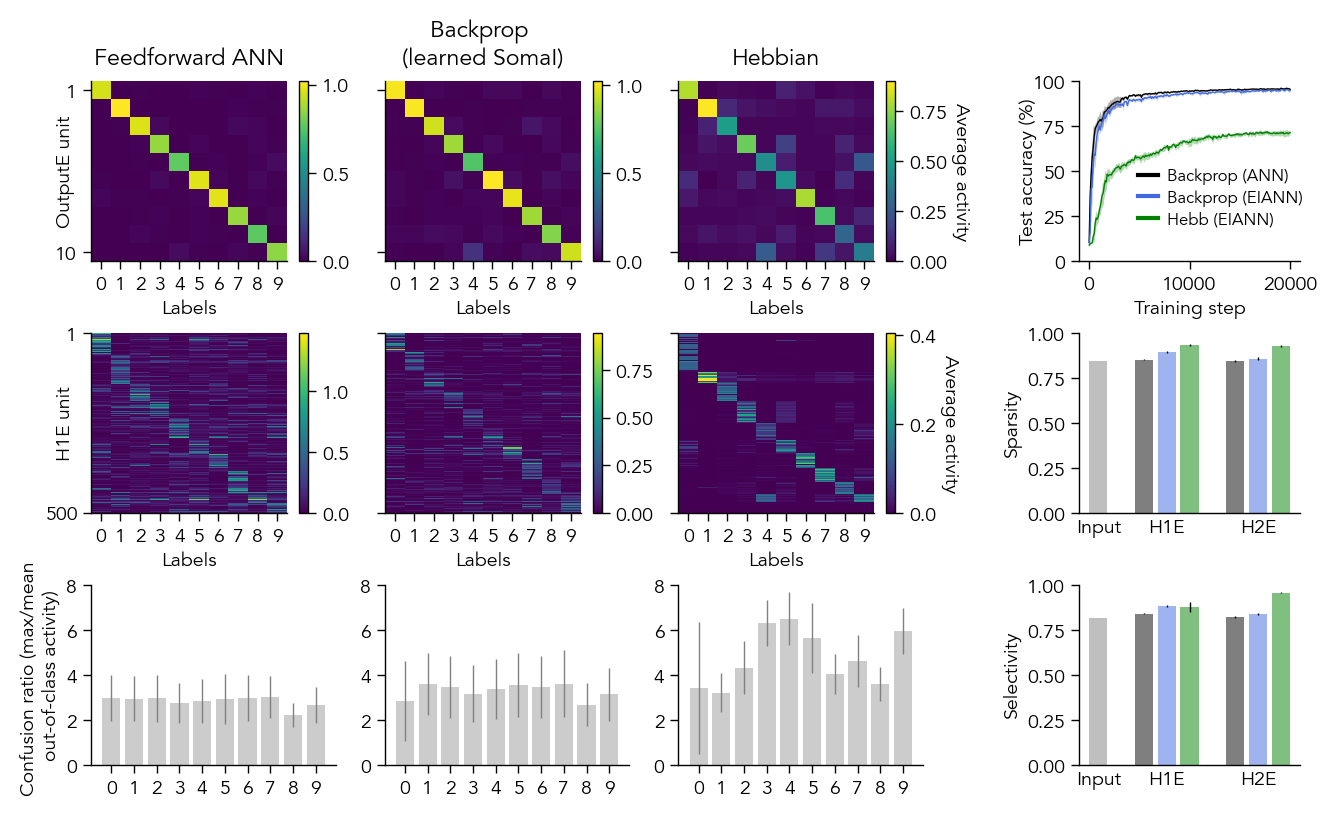

In [4]:
generate_figure_2(model_dict_all, model_list, figure_name)

# Supplementary Figure

In [5]:
figure_name = "Fig2_supplementary"
model_list = ["vanBP", "bpDale_learned", "bpDale_fixed", "HebbWN_topsup", "bpLike_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

Generating plots for Backprop (ANN)
Generating plots for Backprop (EIANN)
Generating plots for Backprop (EIANN)
Generating plots for Hebb (EIANN)
Generating plots for Dend. Target Prop.


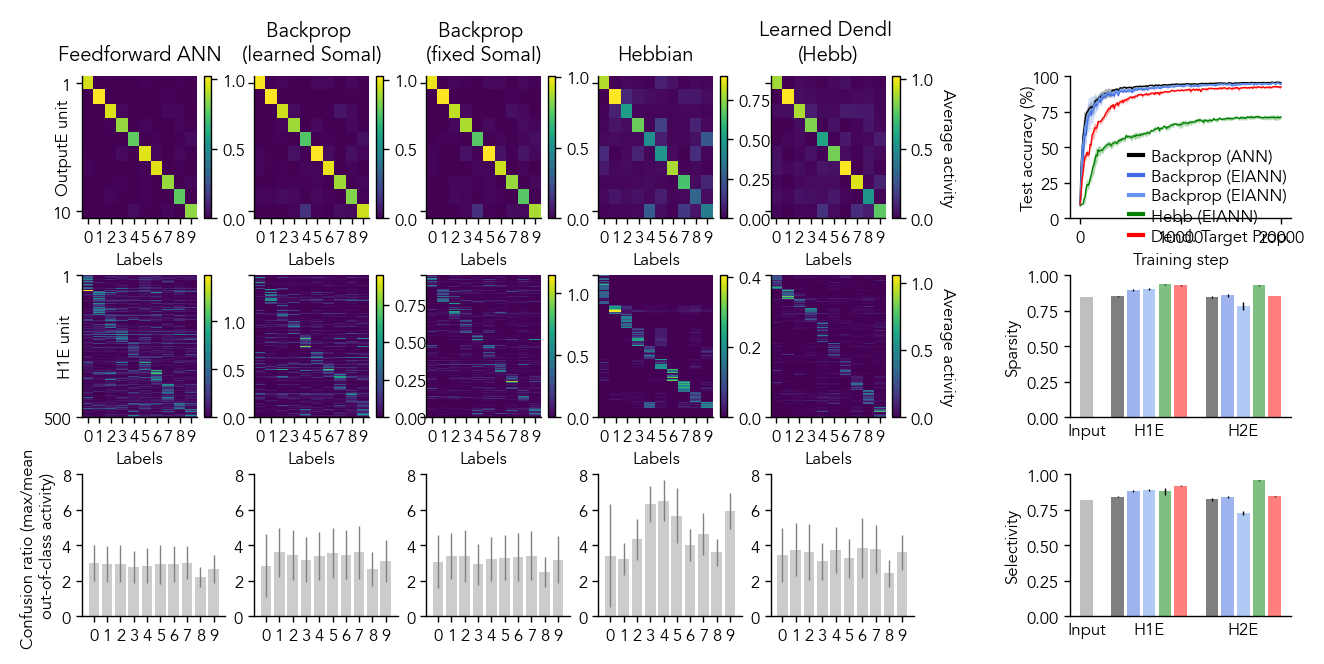

In [9]:
generate_figure_2(model_dict_all, model_list, figure_name, figsize=(6.5, 3))